# 01 - Analise Exploratoria de Dados (EDA)

## Dataset: Breast Cancer Wisconsin
Dados de tumores de mama com caracteristicas extraidas de imagens de biopsia.
**Alvo:** `diagnosis` - M (Maligno) ou B (Benigno)

In [1]:
# Importacoes necessarias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configuracao visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1. Download e Carregamento dos Dados

Uso do `kagglehub` para baixar o dataset automaticamente.
Em sua primeira execucao ele vai fazer o download, e nas seguintes execuões vai usar o cache local.

Nessa etapa, é necessário ter a Kaggle API key configurada

In [2]:
# Baixa o dataset automaticamente do Kaggle
path = kagglehub.dataset_download('uciml/breast-cancer-wisconsin-data')

print('Dataset salvo em:', path)
print('Arquivos disponiveis:', os.listdir(path))

Dataset salvo em: C:\Users\guirr\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2
Arquivos disponiveis: ['data.csv']


In [3]:
# Carrega o CSV principal
csv_path = os.path.join(path, 'data.csv')
df = pd.read_csv(csv_path)

print(f'Shape do dataset: {df.shape}')  # (linhas, colunas)
df.head()

Shape do dataset: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2. Visao Geral dos Dados

In [4]:
# Tipos de dados e valores nulos por coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
# Estatisticas descritivas
# Mostra media, desvio padrao, minimo, maximo e quartis de cada coluna numerica
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [6]:
# Verifica valores nulos por coluna
nulos = df.isnull().sum()
print('Valores nulos por coluna:')
print(nulos[nulos > 0] if nulos.any() else 'Nenhum valor nulo encontrado!')

Valores nulos por coluna:
Unnamed: 32    569
dtype: int64


## 3. Distribuicao da Variavel Alvo



diagnosis
B    357
M    212
Name: count, dtype: int64


C:\Users\guirr\AppData\Local\Temp\ipykernel_32308\962290456.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


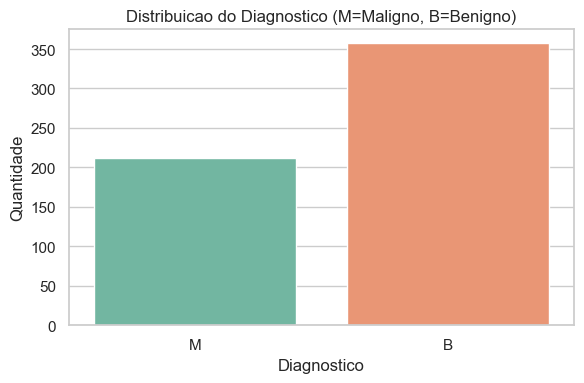

In [7]:
contagem = df['diagnosis'].value_counts()
print(contagem)

plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Distribuicao do Diagnostico (M=Maligno, B=Benigno)')
plt.xlabel('Diagnostico')
plt.ylabel('Quantidade')
plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/distribuicao_diagnostico.png', dpi=150)
plt.show()

## 4. Analise de Correlacao

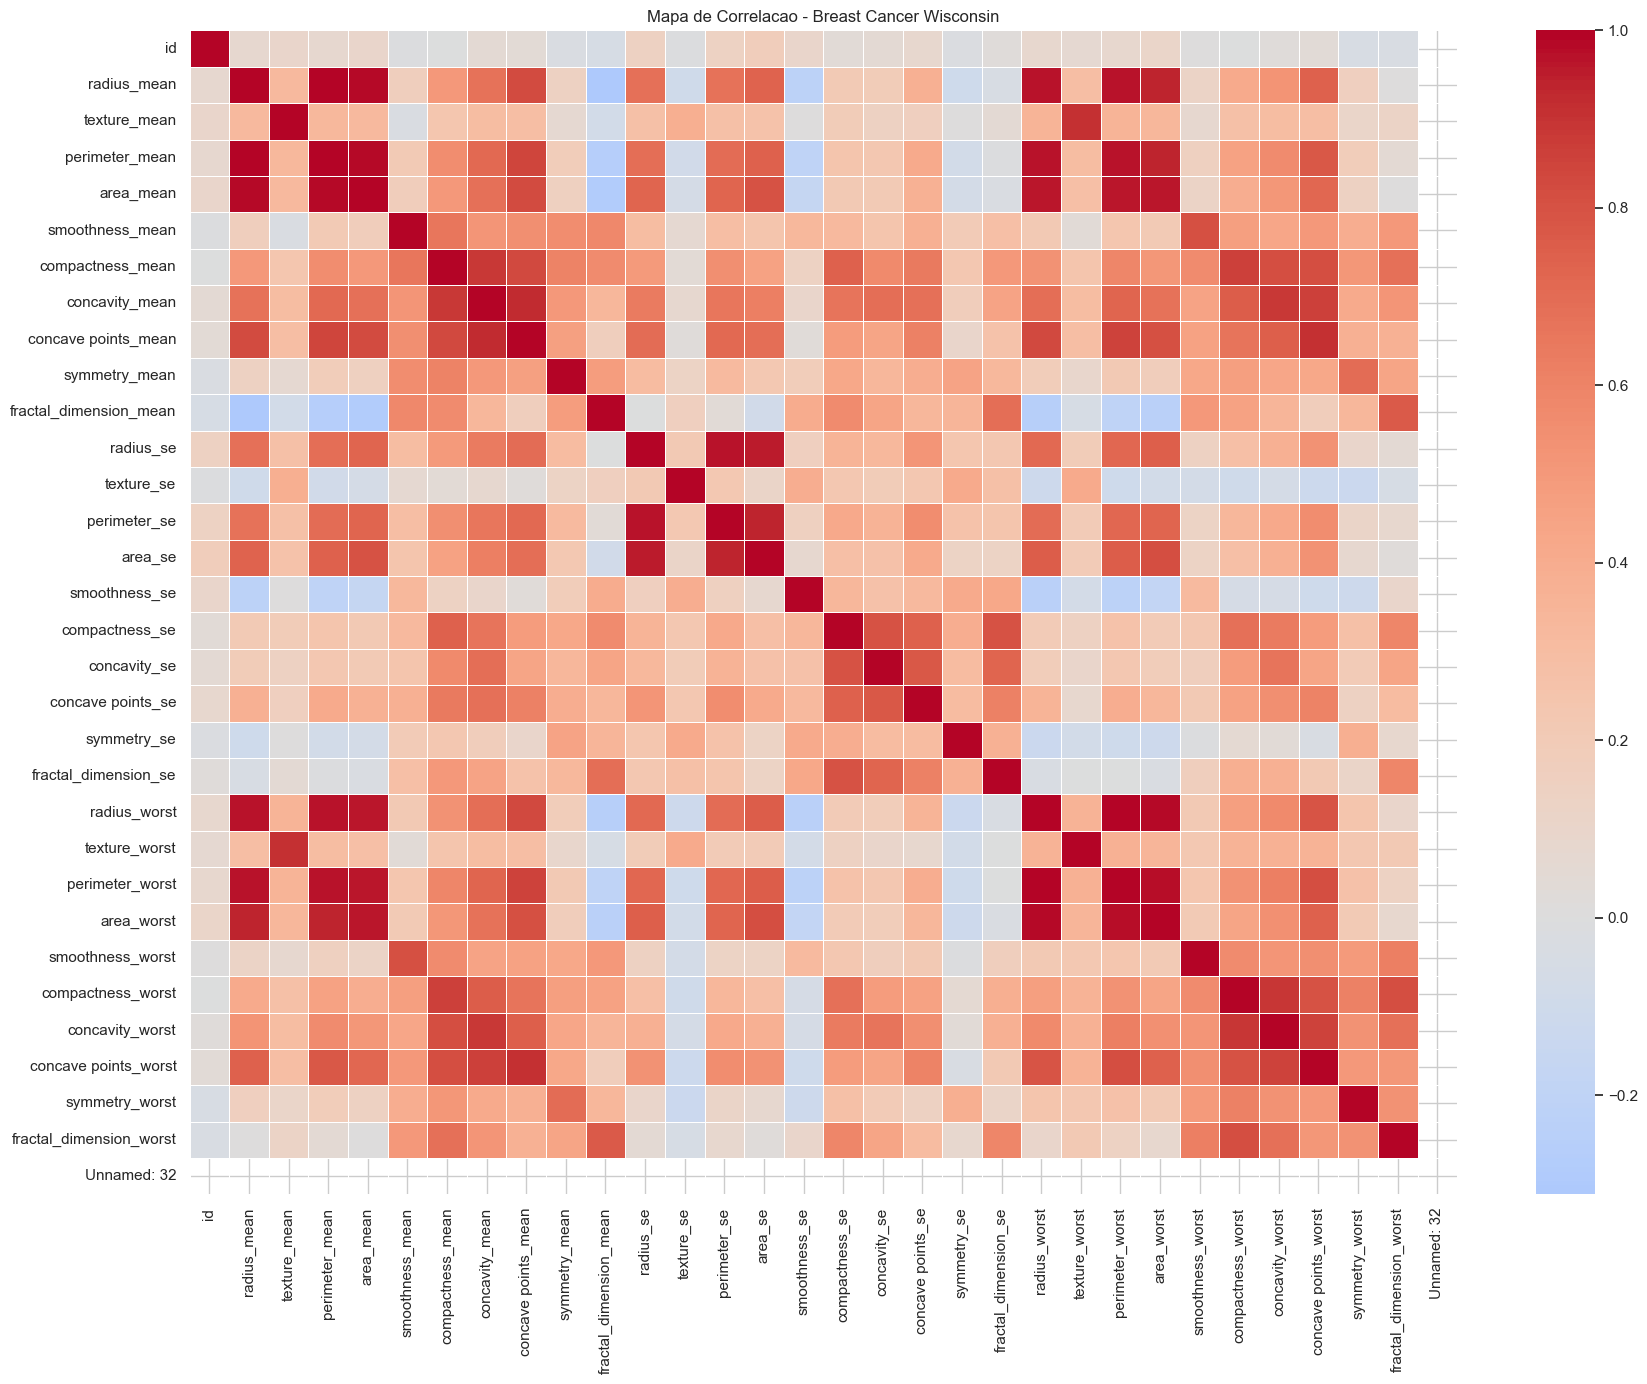

In [8]:
# Seleciona apenas colunas numericas
numericas = df.select_dtypes(include=np.number)

plt.figure(figsize=(18, 14))
sns.heatmap(numericas.corr(), cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de Correlacao - Breast Cancer Wisconsin')
plt.tight_layout()
plt.savefig('../outputs/figures/heatmap_correlacao.png', dpi=150)
plt.show()

## 5. Distribuicao das Principais Features

Visualizamos como as principais variaveis se distribuem para casos Malignos vs Benignos.
Se uma variavel separa bem as duas cores, ela tem alto poder preditivo.

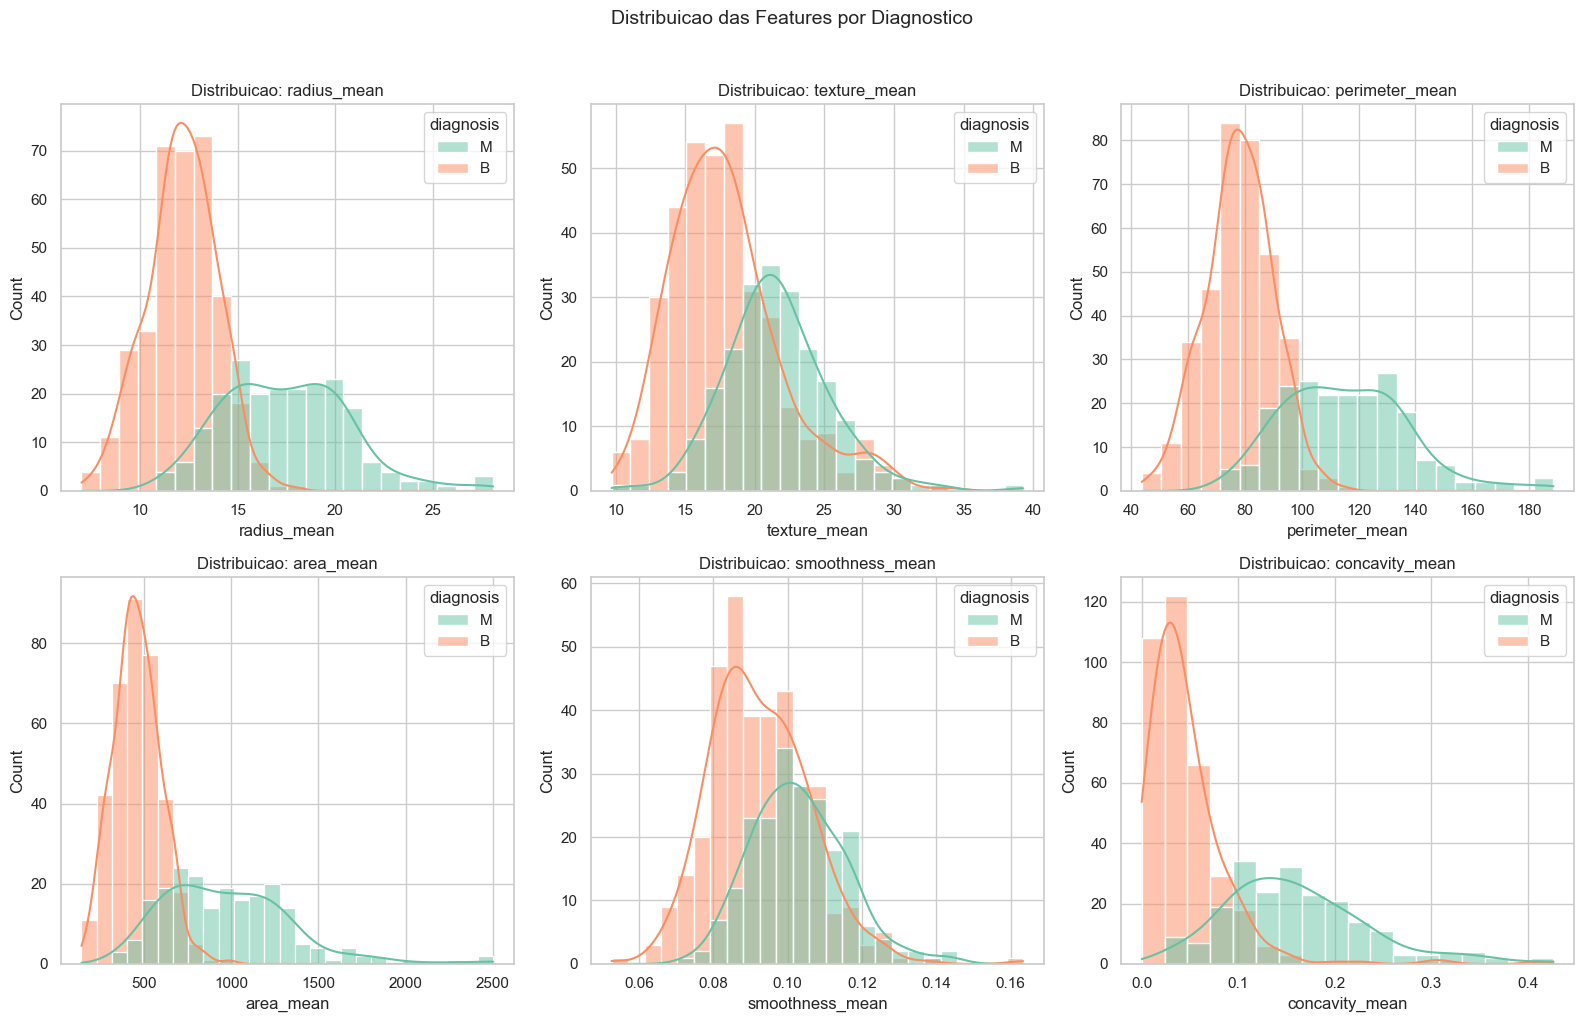

In [9]:
features_relevantes = [
    'radius_mean', 'texture_mean', 'perimeter_mean',
    'area_mean', 'smoothness_mean', 'concavity_mean'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features_relevantes):
    sns.histplot(
        data=df, x=feature, hue='diagnosis',
        kde=True, ax=axes[i], palette='Set2'
    )
    axes[i].set_title(f'Distribuicao: {feature}')

plt.suptitle('Distribuicao das Features por Diagnostico', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/distribuicao_features.png', dpi=150)
plt.show()

## 6. Conclusoes da EDA

- **Shape do dataset:** 569 linhas x 33 colunas
- **Valores nulos:** Nenhum valor nulo nas features. Coluna `Unnamed: 32` estava vazia, logo ela foi removida.
- **Balanceamento:** Maligno: 212 (37,3%) | Benigno: 357 (62,7%) — desbalanceamento moderado, recomenda-se usar F1-score e Recall como metricas principais em vez de accuracy.
- **Principais features discriminantes:** `radius_mean`, `perimeter_mean`, `area_mean` e `concavity_mean` apresentam as maiores diferencas de distribuicao entre M e B, indicando alto poder preditivo.
- **Observacoes sobre correlacao:** Forte correlacao entre `radius_mean`, `perimeter_mean` e `area_mean`

---
Proximo passo: **`preprocessamento.ipynb`** - onde será feita a limpeza e preparacao dos dados para modelagem.
